# Spending → GPU-hours → Compute Model

Converts an AI lab's total compute spending into estimated GPU-hours and average H100-equivalents.

Four Hopper/Blackwell mix scenarios (All Hopper, two weighted mixes from chip stock data, All Blackwell) are each evaluated under low and high price assumptions.

In [1]:
import numpy as np
import pandas as pd

## Parameters

In [2]:
HOURS_PER_YEAR = 8760

# OpenAI compute spending
SPEND_2025 = 16.3e9

# 2024 compute spend uses a two-year amortization schedule for ~$1B of long-term
# research compute. The total is sensitive to that amortization choice — a longer
# schedule lowers the 2024 figure, a shorter one raises it.
SPEND_2024 = 6.8e9

# Price per chip-hour ($/hr) — low and high reference scenarios
HOPPER_PRICE = {'low': 1.5, 'high': 2.0}
BLACKWELL_PRICE = {'low': 3.0, 'high': 4.0}

# H100-equivalent performance ratio per chip
HOPPER_H100E = 1.0
BLACKWELL_H100E = 2.527806

# 2025 estimate

## Hopper vs Blackwell mix

I assume (as reference assumptions) that chips available for rent on the cloud lag actual Nvidia chip sales by ~1–2 quarters. I combined this with cumulative chip stock estimates to estimate what fraction of cloud spending goes to Hopper vs Blackwell.

Using cumulative chip counts, we can compute each chip family's revenue per hour, which is equal to cumulative stock  × price/hr. This then determines how cloud compute spending in that quarter would be split between Hopper and Blackwell. We then weight across a 4-quarter window to get an average share for CY 2025.

Two windows give us a range:
- **Higher Hopper share**: Q3 2024 – Q2 2025 (chips available lag sales by ~2 quarters)
- **Lower Hopper share**: Q4 2024 – Q3 2025 (chips available lag sales by ~1 quarter)

In [3]:
# Cumulative chip stock by quarter (median estimates of Nvidia chips sold)
CHIP_STOCK = {
    'Q3 2024': {'H100/H200': 2_927_767, 'B200/B300': 0},
    'Q4 2024': {'H100/H200': 3_608_873, 'B200/B300': 200_737},
    'Q1 2025': {'H100/H200': 3_937_891, 'B200/B300': 720_370},
    'Q2 2025': {'H100/H200': 4_166_599, 'B200/B300': 1_370_044},
    'Q3 2025': {'H100/H200': 4_293_907, 'B200/B300': 2_257_908},
    'Q4 2025': {'H100/H200': 4_317_291, 'B200/B300': 3_419_254},
}

# Reference prices for computing the spending split (use low prices, matching the spreadsheet)
HOPPER_REF_PRICE = 1.5
BLACKWELL_REF_PRICE = 3.0

# Show per-quarter Hopper share
stock_rows = []
for q, stocks in CHIP_STOCK.items():
    h_rev = stocks['H100/H200'] * HOPPER_REF_PRICE
    b_rev = stocks['B200/B300'] * BLACKWELL_REF_PRICE
    total = h_rev + b_rev
    stock_rows.append({
        'Quarter': q,
        'H100/H200 stock': f'{stocks["H100/H200"]:,}',
        'B200/B300 stock': f'{stocks["B200/B300"]:,}',
        'Hopper rev/hr': f'{h_rev:,.0f}',
        'Blackwell rev/hr': f'{b_rev:,.0f}',
        'Hopper share': f'{h_rev / total:.1%}' if total > 0 else '100.0%',
    })
pd.DataFrame(stock_rows)

,Quarter,H100/H200 stock,B200/B300 stock,Hopper rev/hr,Blackwell rev/hr,Hopper share
0,Q3 2024,"2,927,767",0,"4,391,650",0,100.0%
1,Q4 2024,"3,608,873","200,737","5,413,310","602,211",90.0%
2,Q1 2025,"3,937,891","720,370","5,906,836","2,161,110",73.2%
3,Q2 2025,"4,166,599","1,370,044","6,249,898","4,110,132",60.3%
4,Q3 2025,"4,293,907","2,257,908","6,440,860","6,773,724",48.7%
5,Q4 2025,"4,317,291","3,419,254","6,475,936","10,257,762",38.7%


In [4]:
def compute_weighted_hopper_share(quarter_range):
    """Weighted average Hopper share across quarters, weighted by total revenue capacity."""
    total_hopper_rev = 0
    total_rev = 0
    for q in quarter_range:
        h = CHIP_STOCK[q]['H100/H200'] * HOPPER_REF_PRICE
        b = CHIP_STOCK[q]['B200/B300'] * BLACKWELL_REF_PRICE
        total_hopper_rev += h
        total_rev += h + b
    return total_hopper_rev / total_rev

higher_hopper_share = compute_weighted_hopper_share(['Q3 2024', 'Q4 2024', 'Q1 2025', 'Q2 2025'])
lower_hopper_share = compute_weighted_hopper_share(['Q4 2024', 'Q1 2025', 'Q2 2025', 'Q3 2025'])

print(f'Weighted Hopper share (Q3 2024 – Q2 2025): {higher_hopper_share:.4f}')
print(f'Weighted Hopper share (Q4 2024 – Q3 2025): {lower_hopper_share:.4f}')

Weighted Hopper share (Q3 2024 – Q2 2025): 0.7616
Weighted Hopper share (Q4 2024 – Q3 2025): 0.6376


## Converting spending to chip-hours and H100e

For each mix scenario and price scenario:
- **Hopper spend** = total spend × Hopper share
- **Hopper-hours** = Hopper spend / Hopper price per hour
- **Blackwell-hours** = Blackwell spend / Blackwell price per hour
- **Average H100e across year** = (Hopper-hours × 1.0 + Blackwell-hours × 2.53) / 8760

In [5]:
MIX_SCENARIOS = {
    'All Hopper':        1.0,
    'Higher Hopper mix': higher_hopper_share,
    'Lower Hopper mix':  lower_hopper_share,
    'All Blackwell':     0.0,
}

PRICE_SCENARIOS = {
    'low':  (HOPPER_PRICE['low'],  BLACKWELL_PRICE['low']),
    'high': (HOPPER_PRICE['high'], BLACKWELL_PRICE['high']),
}

def compute_h100e(spend, hopper_share, hopper_price, blackwell_price):
    hopper_spend = spend * hopper_share
    blackwell_spend = spend * (1 - hopper_share)
    hopper_hours = hopper_spend / hopper_price if hopper_price > 0 else 0
    blackwell_hours = blackwell_spend / blackwell_price if blackwell_price > 0 else 0
    h100e = (hopper_hours * HOPPER_H100E + blackwell_hours * BLACKWELL_H100E) / HOURS_PER_YEAR
    return hopper_hours, blackwell_hours, h100e

rows = []
for mix_name, hopper_share in MIX_SCENARIOS.items():
    for price_name, (hp, bp) in PRICE_SCENARIOS.items():
        hopper_hours, blackwell_hours, h100e = compute_h100e(SPEND_2025, hopper_share, hp, bp)
        rows.append({
            'Scenario': mix_name,
            'Hopper share': f'{hopper_share:.1%}',
            'Prices': price_name,
            'Hopper $/hr': f'${hp:.2f}',
            'Blackwell $/hr': f'${bp:.2f}',
            'Hopper-hours': f'{hopper_hours:,.0f}',
            'Blackwell-hours': f'{blackwell_hours:,.0f}',
            'Avg H100e': f'{h100e:,.0f}',
        })

results = pd.DataFrame(rows)
print(f'OpenAI 2025 compute spend: ${SPEND_2025/1e9:.1f}B\n')
results

OpenAI 2025 compute spend: $16.3B



,Scenario,Hopper share,Prices,Hopper $/hr,Blackwell $/hr,Hopper-hours,Blackwell-hours,Avg H100e
0,All Hopper,100.0%,low,$1.50,$3.00,"10,866,666,667",0,"1,240,487"
1,All Hopper,100.0%,high,$2.00,$4.00,"8,150,000,000",0,"930,365"
2,Higher Hopper mix,76.2%,low,$1.50,$3.00,"8,276,372,259","1,295,147,204","1,318,522"
3,Higher Hopper mix,76.2%,high,$2.00,$4.00,"6,207,279,194","971,360,403","988,892"
4,Lower Hopper mix,63.8%,low,$1.50,$3.00,"6,928,618,962","1,969,023,853","1,359,124"
5,Lower Hopper mix,63.8%,high,$2.00,$4.00,"5,196,464,221","1,476,767,889","1,019,343"
6,All Blackwell,0.0%,low,$1.50,$3.00,0,"5,433,333,333","1,567,855"
7,All Blackwell,0.0%,high,$2.00,$4.00,0,"4,075,000,000","1,175,891"


## 2024: Hopper vs A100

Two scenarios for 2024:
- **All Hopper** at $2/hr per chip
- **All A100** at $1/hr per chip — A100s are 312/989 of an H100 in 8-bit TOPS

The $6.8B spend assumes a two-year amortization schedule for ~$1B of long-term research compute — the result is sensitive to that choice.

In [6]:
A100_H100E = 312 / 989

scenarios_2024 = [
    {'name': 'All Hopper', 'price': 2.0, 'h100e_per_chip': HOPPER_H100E},
    {'name': 'All A100',   'price': 1.0, 'h100e_per_chip': A100_H100E},
]

rows_2024 = []
for s in scenarios_2024:
    chip_hours = SPEND_2024 / s['price']
    h100e = chip_hours * s['h100e_per_chip'] / HOURS_PER_YEAR
    rows_2024.append({
        'Scenario': s['name'],
        '$/hr': f"${s['price']:.2f}",
        'H100e per chip': f"{s['h100e_per_chip']:.3f}",
        'Chip-hours': f'{chip_hours:,.0f}',
        'Avg H100e': f'{h100e:,.0f}',
    })

print(f'OpenAI 2024 compute spend: ${SPEND_2024/1e9:.1f}B '
      f'(two-year amortization on ~$1B long-term research compute)\n')
pd.DataFrame(rows_2024)

OpenAI 2024 compute spend: $6.8B (two-year amortization on ~$1B long-term research compute)



,Scenario,$/hr,H100e per chip,Chip-hours,Avg H100e
0,All Hopper,$2.00,1.000,"3,400,000,000","388,128"
1,All A100,$1.00,0.315,"6,800,000,000","244,886"


## Bar graph summary

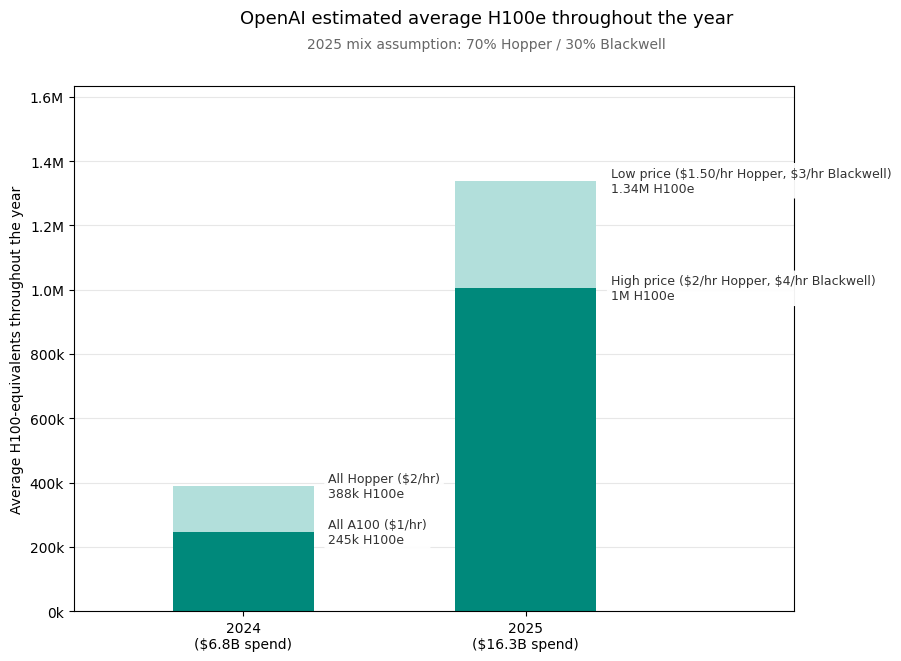

In [7]:
import math

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# One bar per year. The darker teal portion is the lower estimate, and the
# lighter teal portion is the uncertainty range up to the higher estimate.
# The color transition marks the scenario boundary.

def _fmt_price(price):
    if price == int(price):
        return '\\$' + str(int(price))
    return '\\$' + f'{price:.2f}'


def _fmt_sig_figs(value, sig_figs=3):
    """Format a number with up to three significant figures, without trailing zeroes."""
    if value == 0:
        return '0'
    decimal_places = sig_figs - int(math.floor(math.log10(abs(value)))) - 1
    rounded = round(value, decimal_places)
    if decimal_places > 0:
        return f'{rounded:,.{decimal_places}f}'.rstrip('0').rstrip('.')
    return f'{rounded:,.0f}'


def _fmt_h100e(value):
    if value >= 1e6:
        return f'{_fmt_sig_figs(value / 1e6)}M H100e'
    return f'{_fmt_sig_figs(value / 1000)}k H100e'


# 2024: chip-mix scenarios, single price per chip.
scenarios_2024_plot = []
for scenario in scenarios_2024:
    chip_hours = SPEND_2024 / scenario['price']
    h100e = chip_hours * scenario['h100e_per_chip'] / HOURS_PER_YEAR
    label = f"{scenario['name']} ({_fmt_price(scenario['price'])}/hr)"
    scenarios_2024_plot.append((label, h100e))

# 2025: blended Hopper/Blackwell mix, low vs high price scenarios.
blended_hopper_share = (higher_hopper_share + lower_hopper_share) / 2

scenarios_2025_plot = []
for price_name, (hopper_price, blackwell_price) in PRICE_SCENARIOS.items():
    _, _, h100e = compute_h100e(
        SPEND_2025,
        blended_hopper_share,
        hopper_price,
        blackwell_price,
    )
    label = (
        f'{price_name.capitalize()} price '
        f'({_fmt_price(hopper_price)}/hr Hopper, '
        f'{_fmt_price(blackwell_price)}/hr Blackwell)'
    )
    scenarios_2025_plot.append((label, h100e))

year_data = {
    2024: (SPEND_2024, scenarios_2024_plot),
    2025: (SPEND_2025, scenarios_2025_plot),
}

TEAL_DARK = '#00897b'
TEAL_LIGHT = '#b2dfdb'
TEXT_COLOR = '#333333'

fig, ax = plt.subplots(figsize=(11, 7))
x_positions = {2024: 0, 2025: 1}
bar_width = 0.5

all_values = [value for _, scenarios in year_data.values() for _, value in scenarios]
y_top = max(all_values) * 1.22

for year, (spend, scenarios) in year_data.items():
    x = x_positions[year]
    sorted_scenarios = sorted(scenarios, key=lambda item: item[1])
    low_value = sorted_scenarios[0][1]
    high_value = sorted_scenarios[-1][1]

    ax.bar(x, low_value, width=bar_width, color=TEAL_DARK, linewidth=0, zorder=2)
    ax.bar(
        x,
        high_value - low_value,
        width=bar_width,
        bottom=low_value,
        color=TEAL_LIGHT,
        linewidth=0,
        zorder=2,
    )

    x_label = x + bar_width / 2 + 0.05
    for label, h100e in sorted_scenarios:
        ax.annotate(
            f'{label}\n{_fmt_h100e(h100e)}',
            xy=(x_label, h100e),
            xytext=(x_label, h100e),
            textcoords='data',
            va='center',
            ha='left',
            fontsize=9,
            color=TEXT_COLOR,
            bbox=dict(
                boxstyle='round,pad=0.3',
                facecolor='white',
                edgecolor='none',
                alpha=0.95,
            ),
        )


def _yfmt(value, _):
    if value >= 1e6:
        return f'{value / 1e6:.1f}M'
    return f'{value / 1000:.0f}k'


ax.set_xticks(list(x_positions.values()))
ax.set_xticklabels([
    f'{year}\n(${(SPEND_2024 if year == 2024 else SPEND_2025) / 1e9:.1f}B spend)'
    for year in x_positions
])
ax.set_ylabel('Average H100-equivalents throughout the year')
fig.suptitle('OpenAI estimated average H100e throughout the year', fontsize=13, y=0.97)
fig.text(
    0.5,
    0.92,
    f'2025 mix assumption: {blended_hopper_share:.0%} Hopper / '
    f'{1 - blended_hopper_share:.0%} Blackwell',
    ha='center',
    va='center',
    fontsize=10,
    color='#666666',
)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(_yfmt))
ax.set_ylim(0, y_top)
ax.set_xlim(-0.6, 1.95)
ax.grid(True, axis='y', alpha=0.3, zorder=1)
ax.set_axisbelow(True)
fig.subplots_adjust(top=0.86, right=0.78)
plt.show()
